# Hierarchical Bayesian Inference

### Use the emcee package to compute and plot the posterior for the hierarchical Bayesian inference problem you identified in Home 1 Question 3. Discuss your process and your result.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from scipy.stats import lognorm
from scipy.stats import norm
import emcee
f = h5py.File("/Users/relativelyquantum/Programmation/Jupyter/Homework1/Galaxy10_DECals.h5", "r")
galaxy = f["images"]
labels = f["ans"][:]
redshifts = f["redshift"][:]
pxscale= f["pxscale"][:]

### Assignment 1 ,Question 3
From Smith et al. (2003)(reference [1]), they mentionned in chapter 3.2 that "for both late- and early-type galaxies, the intrinsic size distributions can be approximated reasonably well by a lognormal function."  A lognormal function is of the form :$$ Lognormal(\mu,\sigma^2) = \frac{1}{x\sigma \sqrt{2\pi}} \exp [-\frac{(ln x-\mu)^2}{2\sigma^2}] $$
Where $\mu$ is the expected value and $\sigma^2$ is the standard divation.

Even though it's seem there is a confusion about the exact definition of early and late type of galaxy [2], we can categoryse 
early type galaxy as class 2-3-4 and late type of galaxy as class 0-5-6 from Galaxy10 category[3] (The "real" type of galaxy will be unknown for pedagogical purpose).

Our hierachichal bayesian model will try to find the distribution of $\mathcal{R}_e$, which represent the distribution of the early type of galaxy radius. 
We have $$ P(\mathcal{R}_e) \propto Lognormal(\mu,\sigma^2)$$. 

We will try to infere on the distribution by mesuring the reel size of the radius (that will be our data :$x_i$) with the  know informations that we have which are the matrix of the images pixels, the redshifts and the pixel scale of the image. A python library like Photutils will probably be needed [4].

- The first level of parameter, the individual level, will be $\mathcal{R}$. The rayon of the Galaxy
- The second level of parameter, the population level, will be the type of galaxy ($\mathcal{T}_i$ ) i.e early or late.

 The rayon of galaxy (most precisly, the rayon distribution) depend on the type of galaxy as mentionned by [1], meaning that our individul distribution depend on the population distribution. We can then write our hierarchical bayesian model as : 
 $$ P(\mathcal{R}_e ,\mathcal{T}_i| x_i) = P(x_i|\mathcal{T}_i)P(\mathcal{T}_i|\mathcal{R}_e)P(\mathcal{R_e})$$

 But as mentioned above, the galaxy class is unknown. We must therefore sum up all the possibilities. Our final model should look like : $$P(\mathcal{R}_e| x_i) = P(x_i|\mathcal{T}= E)P(\mathcal{T}=E|\mathcal{R}_e)P(\mathcal{R_e}) + P(x_i|\mathcal{T}= L)P(\mathcal{T}=L|\mathcal{R}_e)P(\mathcal{R_e})$$
Where $E$ and $L$ stand for "early" and "late" respectivly. Now since we dont know what is the distribution of $P(x_i|\mathcal{T}_i)P(\mathcal{T}_i)|\mathcal{R}_e)$ for $i \in (E,T)$, we cannot assume that it's will preserve the analytique lognormal distribution. We don't know if we have conjugate priors or not. Speaking of priors, as mentioned here [5], and as we understood in question 2, the choice of priors for the lognormal distribution is a step that should not be taken lightly. Choosing the right priors will be a step that we will take carefully.


In [2]:
good_labels= [0, 2, 3, 4, 5, 6, 7] # We will draw one indez from these lebel ( early and late type combine)
random_index = np.where(np.isin(labels, good_labels))[0]
i = np.random.choice(random_index)
radius_image = 35
data = galaxy[i, 256//2 - radius_image : 256//2 + radius_image, 256//2 - radius_image : 256//2 + radius_image, :]

First we need to defined the distance of our galaxy. From assignment 1 we had the flux-luminosity relationship given by : $$ F  = \frac{L}{4\pi D^2} $$ where F is the flux in and L is the luminosity. Solving again for the distance give: 
$$ D = \frac{1}{2}\sqrt{\frac{L}{\pi F}} $$. We will then mesure the pixel radius of the images and using the pxscale (arcsecond per pixel) provided by Galaxy10 DECaLS to converte pixels radius into angular diameter and into real radius with the formula :$$ \text{Radius}_{\text{real}} = \theta \times D$$ 
Where $\theta$ is the angle

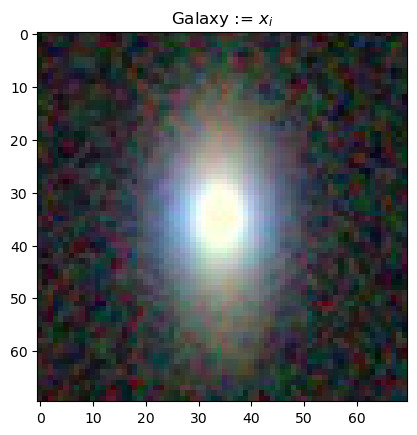

14.527197064122632
Test i= 7224  : Radius =  3.297307497119687 kpc
()


In [3]:
L = 5.37*10**36 # We have no choice to make the approximation that all galaxie have the same luminosity i.e the Milky way one
hubble_cst = 70 # We will used this value of the Hubble constant. In km/Mpc
c = 3*10**5 # Speed of light.In km
plt.imshow(data)
plt.title(rf"Galaxy := $x_i$")
plt.show()
# We first need to defined a way to mesure the radius of the galaxy that will be consistant.
# We choosed the defined the radius as if all galaxy where round.
def rayon_calculator(image):  
    gray = image.mean(axis=2) # We look at the mean of the flux
    threshold = gray.mean() + gray.std()  # we set a 1 sigma threshold of the intensity of the pixel
    mask = gray > threshold
    size_pixels = mask.sum()
    return (size_pixels / np.pi) ** (1/2)

def F_theoric(z):
     return L*(hubble_cst**2)/((4*np.pi *c**2*z**2))

def real_radius(rayon_pixels, pxscale, z):
    distance = (c * z / hubble_cst) * 1e3          # We convert the distance in kpc
    arcsec_radius = rayon_pixels * pxscale               
    rad_radius = arcsec_radius * (np.pi / (180 * 3600)) 
    return distance * rad_radius                     

print(rayon_calculator(data))
print(f'Test i= {i}  :',"Radius = ",real_radius(rayon_calculator(data),pxscale[i],redshifts[i]),"kpc")
print(real_radius(rayon_calculator(data), pxscale[i], redshifts[i]).shape)


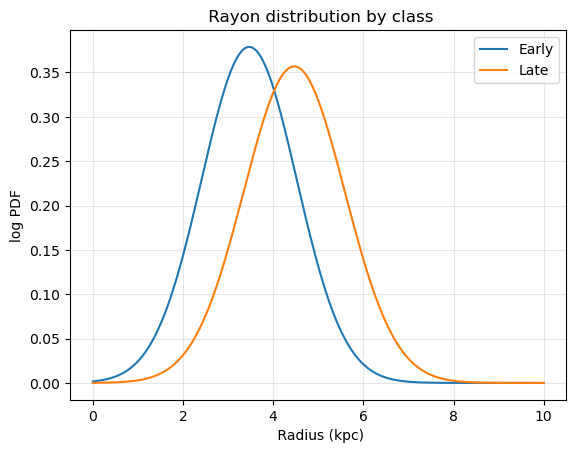

In [4]:
mu_early,sigma_early = 0.54,0.15
mu_late,sigma_late = 0.65,0.22

rayon = np.linspace(0, 10, 1000000)  

p_pdf_early = norm.pdf(rayon,10** mu_early,10** sigma_early**2)
p_pdf_late= norm.pdf(rayon, 10**mu_late,10**sigma_late**2)
plt.plot(rayon, p_pdf_early,label ="Early")
plt.plot(rayon, p_pdf_late,label = "Late")

plt.xlabel(rf" Radius (kpc)")
plt.ylabel("log PDF")
#plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.title(rf" Rayon distribution by class");    

We are know ready to compute and plot the posterior of our probleme. At this point, we realize that since we chose an analytical solution for in Assignment 1, we can also solve the hierarchical Bayesian inference problem analytically. The reason is that $ P(x_i|\mathcal{T}= E)$ and $ P(x_i|\mathcal{T}= L)$, the probability that our data is galaxy type is eithers early or late can be compute. After we have  $P(\mathcal{T}=E|\mathcal{R}_e)$ and $P(\mathcal{T}=L|\mathcal{R}_e)$ where the radius probability function $\mathcal{R}_e$ is independant of the density probability function $P(\mathcal{T}=L)$ for both category. This principle can be expressed as: the galaxies distribution  of each type in the universe is not influenced by their radius. In order to adhere to the instructions and the purpose of the question, we will use a random walk to integrate instead $P(x_i|\mathcal{T}= E)$  and $P(x_i|\mathcal{T}= E)$, of scipy.integrate, for example.
We will set :

prob_xi_e = $P(x_i \mid \mathcal{T}=E)$  
prob_xi_l = $P(x_i \mid \mathcal{T}=L)$  
prob_e    = $P(\mathcal{T}=E)$  
prob_l    = $P(\mathcal{T}=L)$

prob_density_f = $P(\mathcal{R_e}|x_i)$

In [7]:
count_e = np.sum(labels == 2)+  np.sum(labels == 3) + np.sum(labels == 4)
count_l = np.sum(labels == 0)+  np.sum(labels == 5) + np.sum(labels == 6)+np.sum(labels == 7)
prob_e = count_e/(count_e+count_l)
prob_l = count_l/(count_e+count_l)

### Reference :
1 - https://ui.adsabs.harvard.edu/abs/2003MNRAS.343..978S/abstract

In [8]:

def log_prob(x,a,b):
    return -0.5 * ((x[0] - 10**a) / 10**b)**2

def emcee_int(mu,sigma,radius): # We defined our integral function. We followed [1]
    ndim,nwalkers  = 1, 100 # Only 1 parameter,Nomber of Walker

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(mu, sigma)) 

    p0 = mu + sigma * np.random.randn(nwalkers, ndim) # Initial condition, we start at mu.
    sampler.run_mcmc(p0, 500)   
    sampler.reset()
    sampler.run_mcmc(None, 2000) 

    samples = sampler.get_chain(flat=True)[:, 0] # Gather all the iteration and put the result in a 1 D array
    result = np.mean((samples >= 0) & (samples <= radius))# "The integral" Number of sample in the boundaries / total number of sample
    return result


7224


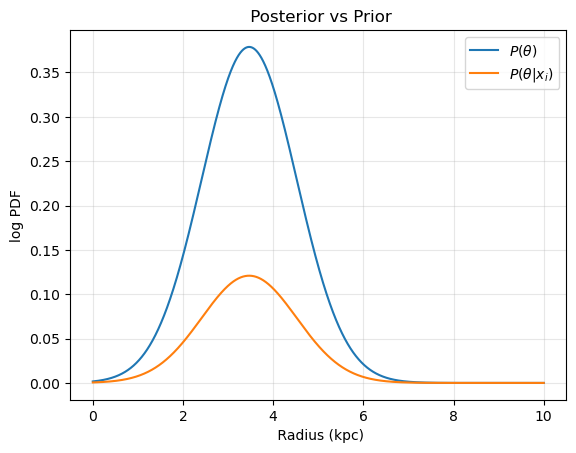

In [9]:
print(i)
prob_xi_e = emcee_int(mu_early,sigma_early,real_radius(rayon_calculator(data),pxscale[i],redshifts[i]))
prob_xi_l =emcee_int(mu_late,sigma_late,real_radius(rayon_calculator(data),pxscale[i],redshifts[i]))

p_pdf_early = norm.pdf(rayon,10** mu_early,10** sigma_early**2)

prob_density_f = (prob_xi_e*prob_e + prob_xi_l*prob_l)*p_pdf_early

plt.plot(rayon, p_pdf_early,label = r'$P(\theta)$')
plt.plot(rayon, prob_density_f,label = r'$P(\theta| x_i)$')

plt.xlabel(rf" Radius (kpc)")
plt.ylabel("log PDF")
#plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.title(rf" Posterior vs Prior");    

The problem is that some galaxies hardly change our prior. The model used to estimate the radius is very rudimentary. Furthermore, in reality, we don’t know the exact ratio of galaxies of each type. Here, we take the average of the images in the Galaxy10 DECaLS Dataset. It’s a bit like cheating.

[1] - https://emcee.readthedocs.io/en/stable/